<a href="https://colab.research.google.com/github/boniphacebenja78-lgtm/lab-2-predictive-analytics/blob/main/lab_2_predictive_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# setting setups and import
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Callable, Dict, Iterable, List, Optional, Tuple
import heapq
import itertools
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [ ]:
# Student Name: [BONIPHACE BENJMAIN] Student
# ID: [75052028]

In [2]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# You will import the specific scikit-learn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42   # use this everywhere so your results are reproducible

# Dataset URLs (already provided for you)
TAXI_URL    = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv"
OBESITY_URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/GkDzb7bWrtvGXdPOfk6CIg/Obesity-level-prediction-dataset.csv"

.....Taxi Dataset.....
(41202, 13)
--- DataFrame Head ---


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
0,2,1,17.63,2,1,132,164,1,70.0,0.5,6.94,1,16.54
1,2,1,19.52,2,1,132,236,1,70.0,0.5,6.94,1,16.19
2,2,1,17.81,2,1,132,48,1,70.0,0.5,6.94,1,12.00
3,2,2,19.30,2,1,132,148,1,70.0,0.5,0.00,1,5.00
4,2,1,18.75,2,1,132,234,1,70.0,0.5,6.94,1,10.00



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41202 entries, 0 to 41201
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   VendorID               41202 non-null  int64  
 1   passenger_count        41202 non-null  int64  
 2   trip_distance          41202 non-null  float64
 3   RatecodeID             41202 non-null  int64  
 4   store_and_fwd_flag     41202 non-null  int64  
 5   PULocationID           41202 non-null  int64  
 6   DOLocationID           41202 non-null  int64  
 7   payment_type           41202 non-null  int64  
 8   fare_amount            41202 non-null  float64
 9   mta_tax                41202 non-null  float64
 10  tolls_amount           41202 non-null  float64
 11  improvement_surcharge  41202 non-null  int64  
 12  tip_amount             41202 non-null  float64
dtypes: float64(5), int64(8)
memory usage: 4.1 MB

--- Descriptive Statistics ---


,VendorID,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,mta_tax,tolls_amount,improvement_surcharge,tip_amount
count,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000,41202.0,41202.000000,41202.000000,41202.000000,41202.000000,41202.000000
mean,2.0,1.633926,18.384928,2.025411,0.999393,132.220475,164.546333,1.0,69.986150,0.491020,5.608198,0.999976,14.107666
std,0.0,0.924250,2.856605,0.461587,0.024625,7.726159,67.901529,0.0,6.184851,0.066404,2.979348,0.004927,5.030619
min,2.0,1.000000,0.000000,1.000000,0.000000,10.000000,3.000000,1.0,3.700000,0.000000,0.000000,0.000000,0.010000
25%,2.0,1.000000,17.370000,2.000000,1.000000,132.000000,113.000000,1.0,70.000000,0.500000,6.940000,1.000000,10.000000
50%,2.0,1.000000,18.180000,2.000000,1.000000,132.000000,163.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
75%,2.0,2.000000,19.380000,2.000000,1.000000,132.000000,231.000000,1.0,70.000000,0.500000,6.940000,1.000000,16.190000
max,2.0,8.000000,189.910000,5.000000,1.000000,264.000000,265.000000,1.0,199.700000,0.500000,57.000000,1.000000,98.000000


VendorID                 0
passenger_count          0
trip_distance            0
RatecodeID               0
store_and_fwd_flag       0
PULocationID             0
DOLocationID             0
payment_type             0
fare_amount              0
mta_tax                  0
tolls_amount             0
improvement_surcharge    0
tip_amount               0
dtype: int64


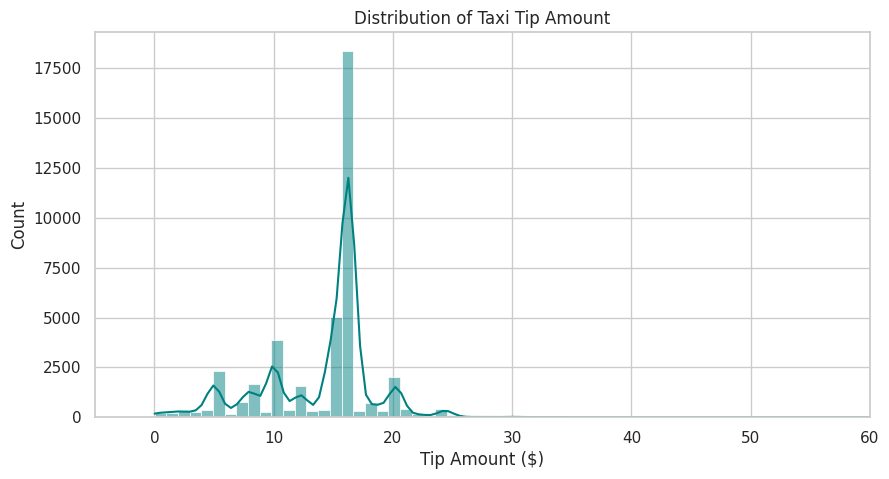

In [6]:
# SECTION A

# PART 1.1

# load the taxi dataset from TAXI_URL into a Dataframe called "taxi:"
print(".....Taxi Dataset.....")
taxi = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/pu9kbeSaAtRZ7RxdJKX9_A/yellow-tripdata.csv")

# Inspect it
print(taxi.shape)

print("--- DataFrame Head ---")
display(taxi.head())

print("\n--- DataFrame Info ---")
taxi.info()

print("\n--- Descriptive Statistics ---")
display(taxi.describe())

# missing values per column
print(taxi.isna().sum())

# visualise the distribution of the target 'tip_amount'
plt.figure(figsize=(10, 5))

sns.histplot(data=taxi, x='tip_amount', bins=100, kde=True, color='teal')
plt.title("Distribution of Taxi Tip Amount")
plt.xlabel("Tip Amount ($)")
plt.ylabel("Count")
plt.xlim(-5, 60)
plt.show()

In [8]:
# PART 1.2

# handle missing values/ invalid rows
taxi_cleaned = taxi[
    (taxi['trip_distance'] > 0) &
    (taxi['fare_amount'] > 0) &
    (taxi['tip_amount'] >= 0) &
    (taxi['tip_amount'] <= 50)
].copy()
#remove row with missing value
taxi_cleaned = taxi_cleaned.dropna()

print(f"Rows before cleaning: {taxi.shape[0]} | Rows after cleaning: {taxi_cleaned.shape[0]}")

#feature enginering
taxi_cleaned['fare_per_mile'] = taxi_cleaned['fare_amount'] / taxi_cleaned['trip_distance']
taxi_cleaned['total_surcharges'] = taxi_cleaned['mta_tax'] + taxi_cleaned['tolls_amount'] + taxi_cleaned['improvement_surcharge']

#decide which columns are categorical and encode the categoricals
categorical_cols = ['VendorID', 'RatecodeID', 'payment_type']
numeric_cols = ['passenger_count', 'trip_distance', 'fare_amount', 'fare_per_mile', 'total_surcharges']

X_reg_raw = taxi_cleaned[numeric_cols + categorical_cols].copy()
y_reg_raw = taxi_cleaned['tip_amount'].copy()

#cast categoricals columns to string so pd.get  treats them as categoricals
for col in categorical_cols:
    X_reg_raw[col] = X_reg_raw[col].astype(str)

#one hot encode the categroricals variables
X_reg_encoded = pd.get_dummies(X_reg_raw, columns=categorical_cols, drop_first=True)

print(f"Features shape after encoding: {X_reg_encoded.shape}")

# scalling the numric features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_reg_scaled = scaler.fit_transform(X_reg_encoded)





Rows before cleaning: 41202 | Rows after cleaning: 41099
Features shape after encoding: (41099, 8)


In [11]:
# PART 1.3 - TRAIN/ VALIDATION/ TEST SPLIT

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Separate features x and target y = tip_amount
X = X_reg_encoded
y = y_reg_raw

# split into train
# Step 1: Split off the test set (20% of the entire dataset)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)
#Split the remaining 80%
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=RANDOM_STATE
)

print(f"Training set shape:   {X_train.shape}")
print(f"Validation set shape: {X_val.shape}")
print(f"Test set shape:       {X_test.shape}")

# Fit your scalr on the TRAINING set only
scaler = StandardScaler()
scaler.fit(X_train)
#apply
X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

#print
print(f"Training set shape:   {X_train_scaled.shape}")
print(f"Validation set shape: {X_val_scaled.shape}")
print(f"Test set shape:       {X_test_scaled.shape}")




Training set shape:   (24659, 8)
Validation set shape: (8220, 8)
Test set shape:       (8220, 8)
Training set shape:   (24659, 8)
Validation set shape: (8220, 8)
Test set shape:       (8220, 8)
